## **Классификация для IC50**

Превышает ли значение IC50 медианное значение выборки

In [51]:
#Импортируем библиотеки
import pandas as pd
import numpy as np
from scipy.stats import randint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [52]:
#Загружаем данные после предобработки
df = pd.read_csv('train_data_preprocessed.csv')
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,log_IC50,log_CC50,log_SI
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,3,0,1.979535,5.173221,3.371597
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,3,0,0.572014,1.856738,2.079442
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,3,0,5.415250,5.088474,0.542324
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,4,0,0.995333,4.690023,4.162553
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,4.683348,4.943576,0.832909


In [53]:
#Оставляем только признаки
X = df.drop(columns=[
    'IC50, mM',
    'CC50, mM',
    'SI',
    'log_IC50',
    'log_CC50',
    'log_SI'
])

y = df['log_IC50']

#Удаление признаков с высокой корреляцией
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

len(high_corr_features)
X = X.drop(columns=high_corr_features)

print("Удалено признаков:", len(high_corr_features))
print("Осталось признаков:", X.shape[1])

removed_features_df = pd.DataFrame(
    high_corr_features,
    columns=["Удалённые признаки (высокая корреляция)"]
)

removed_features_df

Удалено признаков: 33
Осталось признаков: 177


,Удалённые признаки (высокая корреляция)
0,MaxEStateIndex
1,HeavyAtomMolWt
2,ExactMolWt
3,NumValenceElectrons
4,MinAbsPartialCharge
5,Chi0
6,Chi0n
7,Chi0v
8,Chi1
9,Chi1n


In [54]:
#преобразуем целевую переменную в бинарные
ic50_median = y.median()
y = (y > ic50_median).astype(int)
y.name = "IC50 > median"
print("Class distribution:")
print(y.value_counts())

Class distribution:
IC50 > median
0    501
1    500
Name: count, dtype: int64


In [55]:
#Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

# Масштабируем признаки
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


(800, 177) (201, 177)


In [56]:
#Для записи результатов
model_results = []

def add_result(model_name, cv_score, y_true, y_pred, y_proba):
    model_results.append({
        'model': model_name,
        'cv_score': cv_score,
        'accuracy': accuracy_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba),
        'f1_score': f1_score(y_true, y_pred)
    })

In [57]:
#Логистическая регрессия
log_reg = LogisticRegression(max_iter=5000,random_state=42)

params = {'C': [0.01, 0.1, 1, 10, 100],'penalty': ['l2'],'solver': ['lbfgs']}

log_grid = GridSearchCV(
    log_reg,
    params,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
log_grid.fit(X_train_scaled, y_train)
log_pred = log_grid.predict(X_test_scaled)
log_proba = log_grid.predict_proba(X_test_scaled)[:, 1]

print('Лучшие параметры:', log_grid.best_params_)
print(f'CV ROC-AUC = {log_grid.best_score_:.4f}')
print(f'Test Accuracy = {accuracy_score(y_test, log_pred):.4f}')
print(f'Test ROC-AUC = {roc_auc_score(y_test, log_proba):.4f}')
print(f'Test F1-score = {f1_score(y_test, log_pred):.4f}')
add_result('LogisticRegression',log_grid.best_score_,y_test,log_pred,log_proba)

Лучшие параметры: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
CV ROC-AUC = 0.7591
Test Accuracy = 0.6915
Test ROC-AUC = 0.7525
Test F1-score = 0.7103


In [58]:
#RandomForest
rf_base = RandomForestClassifier(random_state=42,n_jobs=-1)
param_dist = {'n_estimators': randint(200, 800),'max_depth': randint(5, 40),
    'min_samples_split': randint(2, 15),'min_samples_leaf': randint(1, 8),
    'max_features': ['sqrt', 'log2', None]}

rf_search = RandomizedSearchCV(rf_base,param_distributions=param_dist,n_iter=50,
    scoring='roc_auc',cv=5,random_state=42,n_jobs=-1,verbose=1)

rf_search.fit(X_train, y_train)
rf_pred = rf_search.predict(X_test)
rf_proba = rf_search.predict_proba(X_test)[:, 1]

print("Лучшие параметры:")
print(rf_search.best_params_)
print(f"\nCV ROC-AUC = {rf_search.best_score_:.4f}")
print(f"Test Accuracy = {accuracy_score(y_test, rf_pred):.4f}")
print(f"Test ROC-AUC = {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Test F1-score = {f1_score(y_test, rf_pred):.4f}")

add_result("RandomForestClassifier",rf_search.best_score_,y_test,rf_pred,rf_proba)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры:
{'max_depth': 6, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 627}

CV ROC-AUC = 0.8100
Test Accuracy = 0.7114
Test ROC-AUC = 0.7793
Test F1-score = 0.7315


In [59]:
#GradientBoostingClassifier
gb_params = {'n_estimators': [100, 200, 400],'learning_rate': [0.03, 0.05, 0.1],'max_depth': [2, 3, 4]}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),gb_params,
    scoring='roc_auc',cv=5,n_jobs=-1
)

gb_grid.fit(X_train, y_train)
gb_pred = gb_grid.predict(X_test)
gb_proba = gb_grid.predict_proba(X_test)[:, 1]

print('Лучшие параметры:', gb_grid.best_params_)
print(f'CV ROC-AUC = {gb_grid.best_score_:.4f}')
print(f'Test Accuracy = {accuracy_score(y_test, gb_pred):.4f}')
print(f'Test ROC-AUC = {roc_auc_score(y_test, gb_proba):.4f}')
print(f'Test F1-score = {f1_score(y_test, gb_pred):.4f}')

add_result('GradientBoostingClassifier',gb_grid.best_score_, y_test,gb_pred,gb_proba)

Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
CV ROC-AUC = 0.8025
Test Accuracy = 0.7214
Test ROC-AUC = 0.7865
Test F1-score = 0.7477


In [60]:
#Сравнение моделей
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by='roc_auc',
    ascending=False
).reset_index(drop=True)

results_df

,model,cv_score,accuracy,roc_auc,f1_score
0,GradientBoostingClassifier,0.802516,0.721393,0.786485,0.747748
1,RandomForestClassifier,0.810016,0.711443,0.779257,0.731481
2,LogisticRegression,0.759078,0.691542,0.752525,0.710280


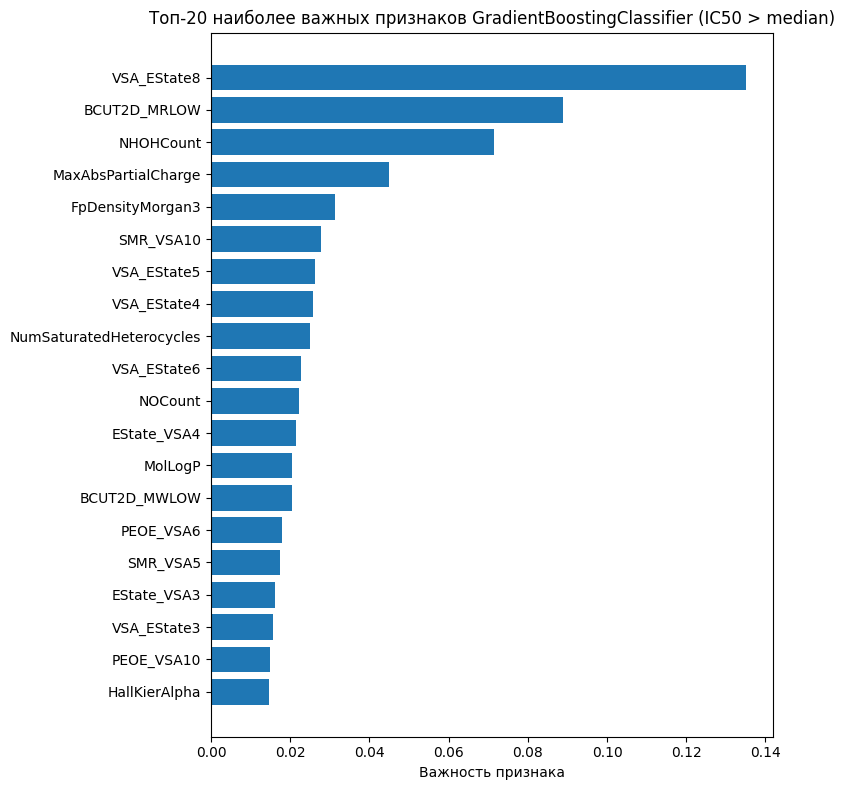

In [61]:
# Важность признаков для GradientBoostingClassifier
best_gb = gb_grid.best_estimator_
importances = best_gb.feature_importances_
feature_names = X.columns

idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 8))
plt.barh(
    range(len(idx)),
    importances[idx][::-1]
)
plt.yticks(
    range(len(idx)),
    feature_names[idx][::-1]
)
plt.xlabel("Важность признака")
plt.title("Топ-20 наиболее важных признаков GradientBoostingClassifier (IC50 > median)")
plt.tight_layout()
plt.show()

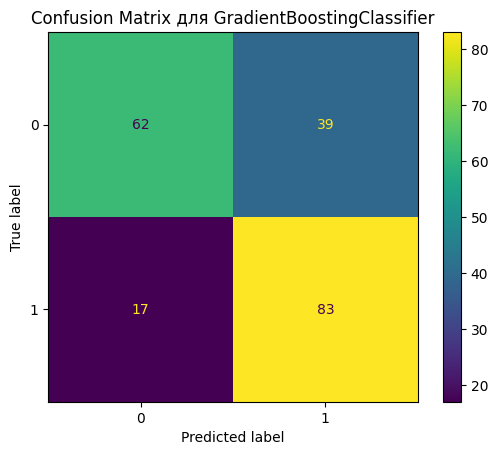

In [62]:
#Матрица ошибок
ConfusionMatrixDisplay.from_estimator(
    gb_grid.best_estimator_,
    X_test,
    y_test
)

plt.title("Confusion Matrix для GradientBoostingClassifier")
plt.show()

Вывод: В ходе работы я предобработал данные - произвел удаление коррелированных признаков и масштабирование признаков. Сравнил модели LogisticRegression с RandomForest и GradientBoosting. Наилучшая модель - GradientBoosting + GridSearchCV. Оценка проводилась по метрикам ROC-AUC, Accuracy и F1-score. По матрице ошибок - модель лучше распознает соединения выше медианного IC50. Наиболее значимый признак - VSA_EState8, который отражает площадь поверхности атомов молекулы, попадающих в определённый диапазон электропологического состояния (EState). Заметим, что в регрессионной модели этот признак так же был наиболее значимым.